# Country Dataset Analysis

In [1]:
# import dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset and Basic Inspection of data

In [2]:
# load the data
df = pd.read_csv("./data/Country-data.csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [3]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.shape

(167, 10)

### Rename Column Names

In [6]:
# Rename Column names for better understaning
rename_dict = {
    'child_mort': 'child_mortality_per_1000',
    'exports': 'exports_gdp_percent',
    'health': 'health_spending_gdp_percent',
    'imports': 'imports_gdp_percent',
    'income': 'net_income_per_capita_usd',
    'inflation': 'inflation_rate_percent',
    'life_expec': 'life_expectancy_years',
    'total_fer': 'total_fertility_rate',
    'gdpp': 'gdp_per_capita_usd'
}

# Update DataFrame
df.rename(columns=rename_dict, inplace=True)

df.head()

,country,child_mortality_per_1000,exports_gdp_percent,health_spending_gdp_percent,imports_gdp_percent,net_income_per_capita_usd,inflation_rate_percent,life_expectancy_years,total_fertility_rate,gdp_per_capita_usd
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [7]:
import os
os.makedirs('plots' , exist_ok=True)
print("Director created successfully")

Director created successfully


## Check Skewness of 
### Hitograms

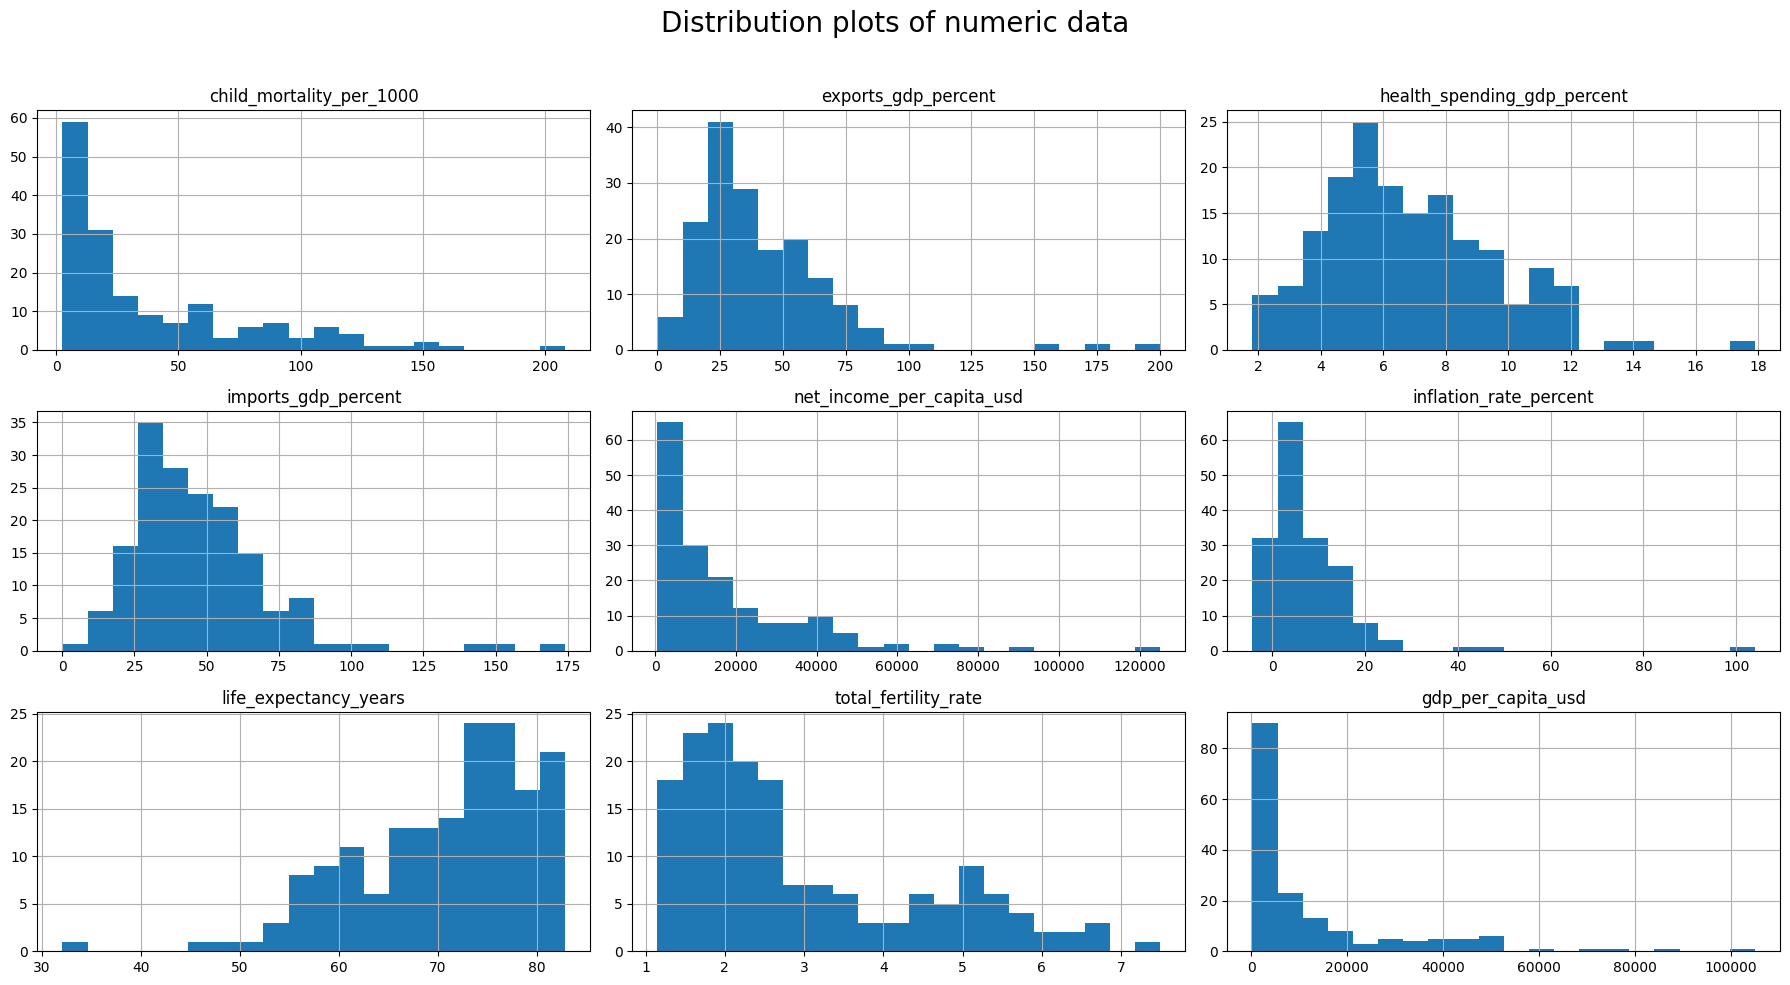

In [8]:
df.hist(figsize=(18,10) , bins=20)
plt.suptitle("Distribution plots of numeric data" , fontsize=20 )
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('plots/01_Distribution_Histograms.png' , dpi=150 , bbox_inches= 'tight')
plt.show()

### Interpretation:
* Most columns are right-skewed : `child_mortality`, `exports_gdp%`, `imports_gdp%`, `net_income`, `inflation_rate`, `total_fertility`.
* `life_expectancy` is left-skewed (most countries cluster at high values 70-80, few at low).
* `health_spending_gdp%` is roughly bell-shaped (closest to normal)

### Boxplots

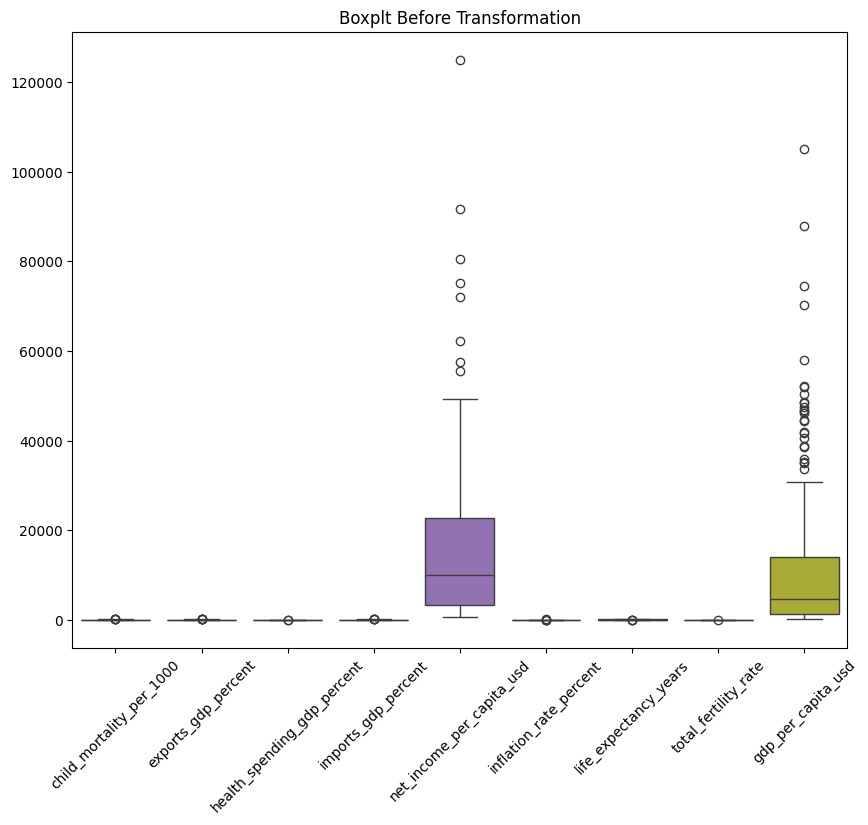

In [9]:
plt.figure(figsize=(10,8))
sns.boxplot(data=df.drop(columns=['country']))
plt.title("Boxplt Before Transformation")
plt.xticks(rotation=45)
plt.savefig('plots/02_boxplot_before _transformation.png' , dpi=150 , bbox_inches= 'tight')
plt.show()

### Interpretaion:

* net_income_per_capita and gdp_per_capita have many outliers (rich countries) and are on a completely different scale (thousands) vs other columns (0-200 range).
* Other variables (`mortality, exports%`, `imports%`, `fertility`) look almost flat here only because they're squished by the huge income/gdp scale.

### Heatmap

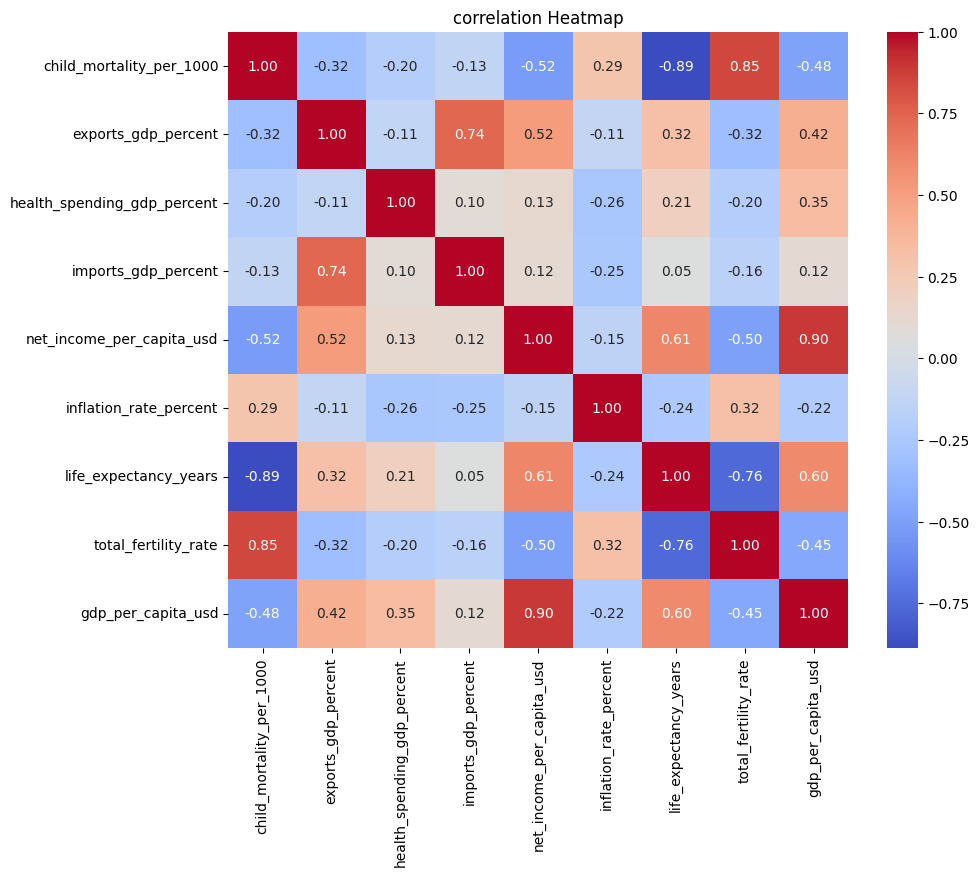

In [10]:
plt.figure(figsize=(10,8))
sns.heatmap(data=df.drop(columns=['country']).corr() , 
            annot=True , cmap = 'coolwarm' , fmt = '.2f')
plt.title('correlation Heatmap') 
plt.savefig('plots/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### Correlation Heatmap Interpretaion
- `child_mortality` ↔ `life_expectancy`: **-0.89** (strong negative — expected)
- `child_mortality` ↔ `total_fertility`: **0.85** (strong positive)
- `net_income` ↔ `gdp_per_capita`: **0.90** (very strong — near duplicate info)
- `exports%` ↔ `imports%`: **0.74** (strong).



### Pairplot

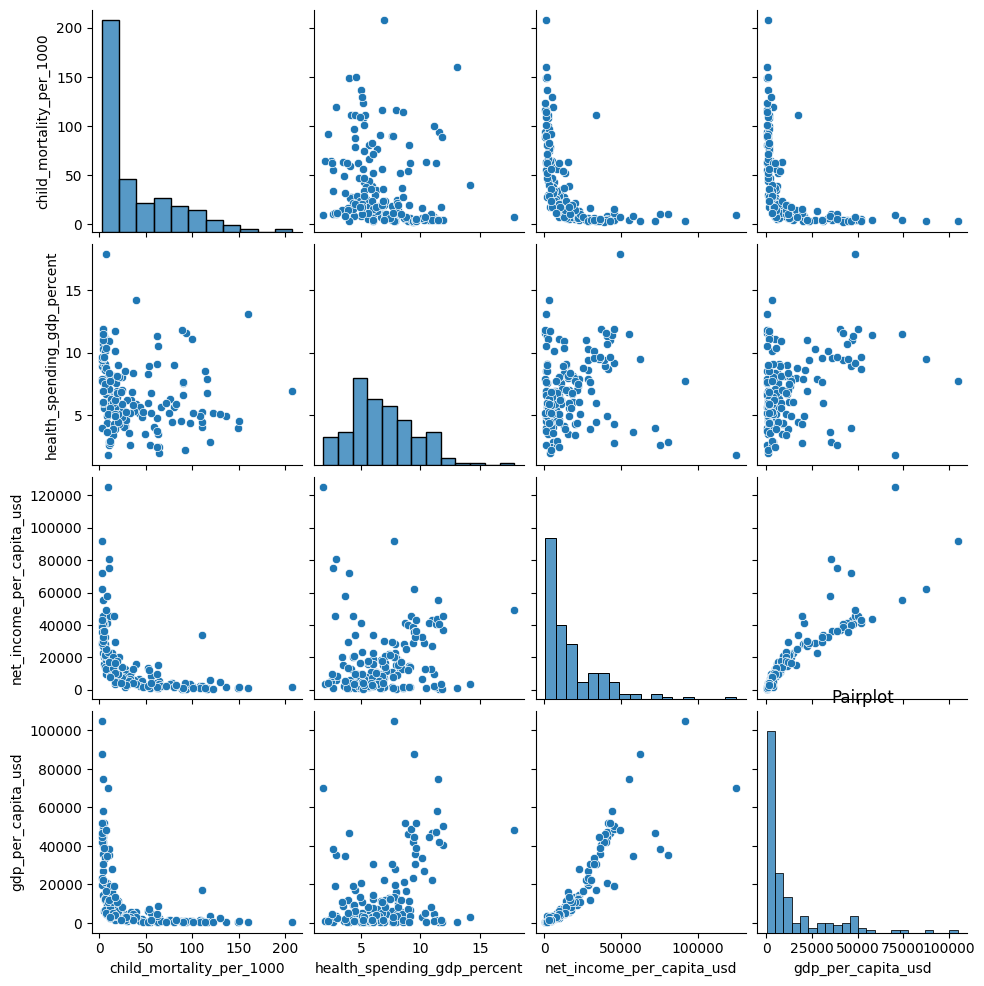

In [11]:
sns.pairplot(df , vars = ['child_mortality_per_1000' ,'health_spending_gdp_percent' ,
                          'net_income_per_capita_usd', 'gdp_per_capita_usd' ])
plt.title("Pairplot")
plt.savefig('plots/04_pairplot_relationships', dpi=150, bbox_inches='tight')
plt.show()

### Pairplot Interpretation:
- `child_mortality` vs `net_income`/`gdp_per_capita` shows a clear **exponential decay curve** , not linear, but a real relationship.
- Points colored by `gdp_per_capita` show natural groupings (poor/developing/rich countries) , this is a good sign that **real clusters exist** in the data.


In [12]:
# check skewness
df.drop(columns=['country']).skew().sort_values(ascending=False)

inflation_rate_percent         5.154049
exports_gdp_percent            2.445824
net_income_per_capita_usd      2.231480
gdp_per_capita_usd             2.218051
imports_gdp_percent            1.905276
child_mortality_per_1000       1.450774
total_fertility_rate           0.967092
health_spending_gdp_percent    0.705746
life_expectancy_years         -0.970996
dtype: float64

### Create Copy of Orignal DataFrame

In [13]:
df_original = df.copy()

### Log Transformation

In [14]:
# List of Skewed columns
skewed_cols = [
    'child_mortality_per_1000',
    'net_income_per_capita_usd', 'exports_gdp_percent', 
    'imports_gdp_percent', 'gdp_per_capita_usd'
]

# Log transformation saved to DataFrame
df[skewed_cols] = np.log1p(df[skewed_cols])

In [15]:
# verify skewness
round(df[skewed_cols].skew() , 4)

child_mortality_per_1000     0.0662
net_income_per_capita_usd   -0.2358
exports_gdp_percent         -1.0890
imports_gdp_percent         -1.8228
gdp_per_capita_usd           0.0065
dtype: float64

### Boxenplot after log transformation

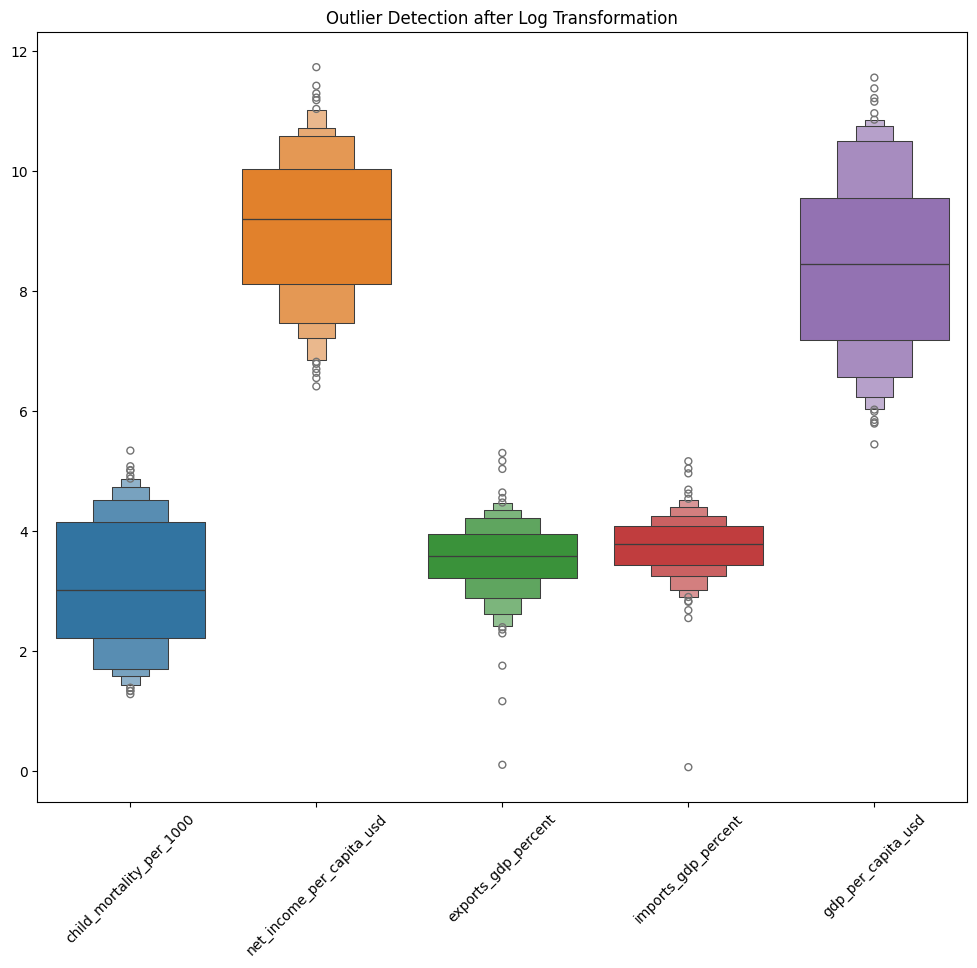

In [16]:
plt.figure(figsize=(12,10))
sns.boxenplot(df[skewed_cols])
plt.title("Outlier Detection after Log Transformation")
plt.xticks(rotation=45)
plt.savefig('plots/05_boxenplot_after_transformation', dpi=150, bbox_inches='tight')
plt.show()

**Column by column:**
- `child_mortality_per_1000` (skew 0.066) → Distribution looks clean and fairly symmetric. Few small outliers at top, but nothing extreme. ✅ Well fixed.
- `gdp_per_capita_usd` (skew 0.0065) → Best-looking one, near-perfect symmetry, minimal outliers at the top only. ✅ Excellent fix.
- `net_income_per_capita_usd` (skew -0.235) → Fairly balanced, few outliers on both ends, acceptable spread. ✅ Good.
- `exports_gdp_percent` (skew -1.09) → Outliers stacked at both top and bottom, tail extends low. ⚠️ Still skewed.
- `imports_gdp_percent` (skew -1.82) → **Worst one** , long tail stretching down to ~0, several low outliers, this is most skewed column even after log. ⚠️ Still noticeably skewed.

### Scaling

In [17]:
from sklearn.preprocessing import StandardScaler

X = df.drop(columns = ['country'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# saved to dataframe
df_scaled = pd.DataFrame(X_scaled , columns=X.columns)


In [18]:
# check scaling

df_scaled.describe()

,child_mortality_per_1000,exports_gdp_percent,health_spending_gdp_percent,imports_gdp_percent,net_income_per_capita_usd,inflation_rate_percent,life_expectancy_years,total_fertility_rate,gdp_per_capita_usd
count,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02,1.670000e+02
mean,-8.110611e-17,-1.002525e-15,5.504579e-16,2.871954e-16,3.483574e-16,-1.063687e-17,3.696311e-16,3.044803e-16,-4.095194e-16
std,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00,1.003008e+00
min,-1.703744e+00,-5.268313e+00,-1.827827e+00,-6.839451e+00,-2.205787e+00,-1.137852e+00,-4.337186e+00,-1.191250e+00,-2.042565e+00
25%,-8.338146e-01,-5.228012e-01,-6.922106e-01,-5.690687e-01,-8.139634e-01,-5.666409e-01,-5.927576e-01,-7.639023e-01,-8.740362e-01
50%,-1.080410e-01,4.633818e-02,-1.810007e-01,8.197954e-02,7.412188e-02,-2.269504e-01,2.869576e-01,-3.564309e-01,-3.557814e-02
75%,9.382085e-01,6.181612e-01,6.515412e-01,6.375661e-01,7.501153e-01,2.816364e-01,7.042584e-01,6.175252e-01,7.020602e-01
max,2.043054e+00,2.672748e+00,4.047436e+00,2.633160e+00,2.139074e+00,9.129718e+00,1.380962e+00,3.009349e+00,2.047997e+00


### Principal Componant Analysis

In [19]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_scaled) 

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

In [20]:
# check how much information each component explains
explained_var = pca.explained_variance_ratio_
cumulative_var = explained_var.cumsum()

print("Variance per Comonent:" , explained_var.round(3))
print("Cumulative Variance:" , cumulative_var.round(3))

Variance per Comonent: [0.528 0.169 0.134 0.082 0.038 0.026 0.014 0.007 0.002]
Cumulative Variance: [0.528 0.697 0.831 0.914 0.951 0.977 0.991 0.998 1.   ]


* **Component 4 gets to 91.4% , crossing the threshold with the fewest components. Component 3 alone only gives 83.1%, not quite enough.**

In [21]:
# apply PCA

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

X_pca = pd.DataFrame(X_pca , columns= ['PCA1' , 'PCA2' , 'PCA3' , 'PCA4'])
X_pca.head()


,PCA1,PCA2,PCA3,PCA4
0,3.617510,-0.065846,1.111141,0.314364
1,-0.683311,-0.086172,0.229897,-0.466841
2,-0.029096,-0.497907,-1.333247,-0.181238
3,2.444211,0.969442,-2.065645,0.486336
4,-1.532919,0.504657,-0.094701,-0.504699


$$J = \sum_{i=1}^{K} \sum_{x \in S_i} \vert{}\vert{}x - \mu_i\vert{}\vert{}^2$$

### Find Optimal K(Elbow Methond & Sillhouette Score)

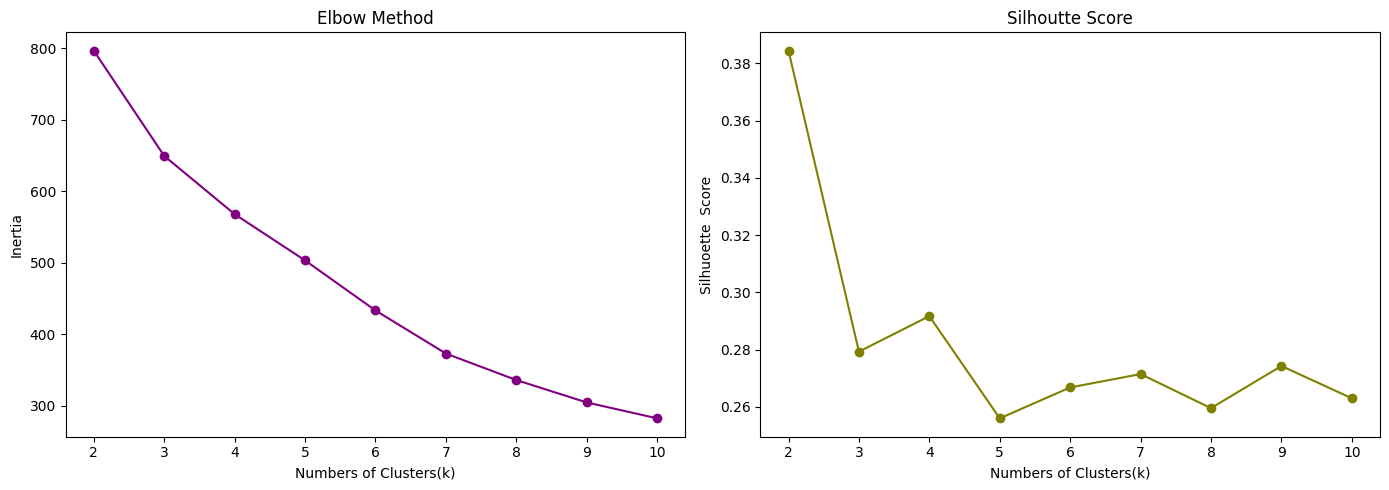

In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
silhouette = []
k_range = range(2,11) # testing k = 2 to 10

for k in k_range:
    km = KMeans(n_clusters=k , random_state=42 , n_init=10)
    labels = km.fit_predict(X_pca)

    wcss.append(km.inertia_)
    silhouette.append(silhouette_score(X_pca , labels))

# plot both

fig , ax = plt.subplots(1,2 , figsize = (14,5))

ax[0].plot(k_range , wcss , marker = 'o' , color = 'purple')
ax[0].set_title("Elbow Method")
ax[0].set_xlabel("Numbers of Clusters(k)")
ax[0].set_ylabel("Inertia")


ax[1].plot(k_range , silhouette , marker = 'o' , color = 'olive')
ax[1].set_title("Silhoutte Score")
ax[1].set_xlabel("Numbers of Clusters(k)")
ax[1].set_ylabel("Silhuoette  Score")

plt.savefig('plots/06_elbow_method_&_silhoutte.png', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

### K-Mean Model training with k=3

In [23]:
kmeans = KMeans(n_clusters=3 , random_state=42 , n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)

# Add cluster labels to original df
df_original['cluster'] = cluster_labels

df_original['cluster'].value_counts()


cluster
0    62
2    59
1    46
Name: count, dtype: int64

In [24]:
round(df_original.groupby('cluster').mean(numeric_only=True) , 3)

,child_mortality_per_1000,exports_gdp_percent,health_spending_gdp_percent,imports_gdp_percent,net_income_per_capita_usd,inflation_rate_percent,life_expectancy_years,total_fertility_rate,gdp_per_capita_usd
cluster,,,,,,,,,
0,28.574,39.990,5.695,43.645,11664.839,10.191,70.813,2.626,5536.387
1,91.583,23.815,6.453,42.658,2172.239,11.298,60.057,4.915,992.783
2,6.893,55.768,8.276,53.600,34576.610,2.509,78.471,1.753,30103.220


### Visualize clusters(PCA1 , PCA2)

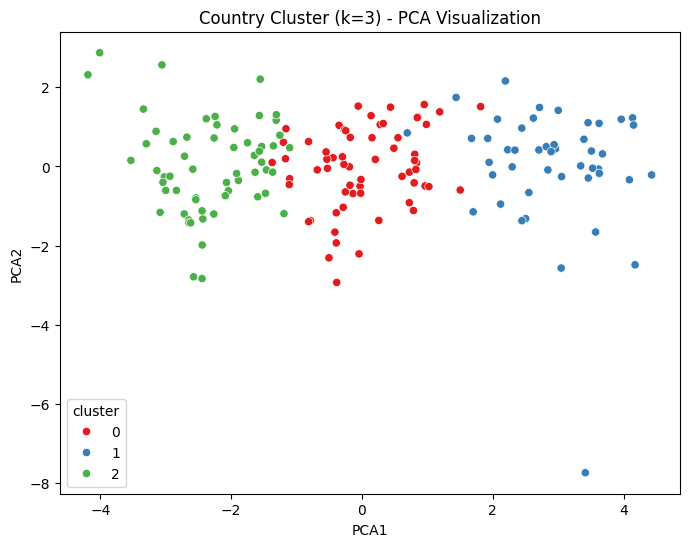

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(x = X_pca['PCA1'] , y = X_pca['PCA2'] , hue = df_original['cluster'] ,
                palette='Set1')
plt.title('Country Cluster (k=3) - PCA Visualization')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.savefig('plots/07_clustering_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

Quick reminder before reading: `child_mortality`, `net_income`, `gdp_per_capita`, `exports%`, `imports%` are **log-transformed** (small numbers like 3-10 are normal here, not raw values). `inflation_rate`, `health_spending`, `life_expectancy`, `total_fertility` are in original scale.


| Feature | Cluster 0 (Developing) | Cluster 1 (Underdeveloped) | Cluster 2 (Developed) |
|---|---|---|---|
| Child mortality | 28.6 | 91.6 | 6.9 |
| Life expectancy | 70.8 | 60.1 | 78.5 |
| Income (USD) | 11,665 | 2,172 | 34,577 |
| GDP per capita (USD) | 5,536 | 993 | 30,103 |
| Inflation | 10.2% | 11.3% | 2.5% |
| Fertility rate | 2.63 | 4.92 | 1.75 |
| Health spending | 5.7% | 6.5% | 8.3% |


## Naming clusters

**Cluster 0 (62 countries) → "Developing Countries"**
Sits in the middle on almost every metric , between developed and underdeveloped. Consistent with real-world distribution (most countries are mid-development, not extremes).

**Cluster 1 (46 countries) → "Underdeveloped / Highest Need"**
Highest child mortality, lowest life expectancy (60 yrs), lowest income/GDP, highest inflation (11.7%), highest fertility (5 children/woman avg). These are the countries that would need aid/support most.

**Cluster 2 (59 countries) → "Developed Countries"**
Lowest child mortality, highest life expectancy (79 yrs), highest income/GDP, lowest inflation, lowest fertility, highest health spending. Textbook high-income nation.




In [26]:
cluster_mapping = {
    0: "Developing",
    1: "Under Developed",
    2: "Developed"
}

df_original['country_status'] = df_original['cluster'].map(cluster_mapping)
df_original.head()

,country,child_mortality_per_1000,exports_gdp_percent,health_spending_gdp_percent,imports_gdp_percent,net_income_per_capita_usd,inflation_rate_percent,life_expectancy_years,total_fertility_rate,gdp_per_capita_usd,cluster,country_status
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,1,Under Developed
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,0,Developing
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,0,Developing
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,1,Under Developed
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,2,Developed


### Save to csv

In [27]:
df_original.to_csv("data/country_data_clustered.csv" , index=False)